## Importación de librerías

In [1]:

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

%matplotlib inline
sns.set_theme()

## Carga, agregación a 90 días y purga de datos sensibles

In [2]:
# 1. Cargar datos
vle_df = pd.read_csv('./../../../dataset/oulad/studentVle.csv')
info_df = pd.read_csv('./../../../dataset/oulad/studentInfo.csv')

vle_90_days = vle_df[vle_df['date'] <= 90]
vle_agg = vle_90_days.groupby(['id_student', 'code_module', 'code_presentation']).agg(
    total_clicks=('sum_click', 'sum'),
    mean_clicks=('sum_click', 'mean'),
    active_days=('date', 'nunique')
).reset_index()

vle_agg.fillna(0, inplace=True)

# 3. Excluir datos sensibles
sensitive_columns = ['gender', 'disability', 'age_band', 'imd_band', 'region']
info_clean = info_df.drop(columns=sensitive_columns)

## Cruce de datos y creación del Target

In [3]:

df_merged = pd.merge(info_clean, vle_agg, on=['id_student', 'code_module', 'code_presentation'], how='inner')

df_merged['target_burnout'] = df_merged['final_result'].apply(lambda x: 1 if x == 'Withdrawn' else 0)

df_merged = df_merged.drop(columns=['final_result', 'id_student'])

## Partición por cursos

In [4]:
df_train = df_merged[df_merged['code_presentation'].str.contains('2013')].copy()

df_test = df_merged[df_merged['code_presentation'].str.contains('2014')].copy()

columnas_a_borrar = ['code_module', 'code_presentation']

X_train = df_train.drop(columns=columnas_a_borrar + ['target_burnout'], errors='ignore')
y_train = df_train['target_burnout']

X_test = df_test.drop(columns=columnas_a_borrar + ['target_burnout'], errors='ignore')
y_test = df_test['target_burnout']

print(f"Alumnos en Histórico (Train 2013): {len(X_train)}")
print(f"Alumnos Nuevos (Test 2014): {len(X_test)}")

Alumnos en Histórico (Train 2013): 12049
Alumnos Nuevos (Test 2014): 16793


## Construcción y Entrenamiento del Pipeline

In [5]:
cat_cols = ['highest_education']
num_cols = ['num_of_prev_attempts', 'studied_credits', 'total_clicks', 'mean_clicks', 'active_days']

# Preprocesador
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ])

# Pipeline Base LogReg
logreg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
   ('classifier', LogisticRegression(l1_ratio=0, solver='saga', class_weight='balanced', max_iter=2000, random_state=42))
])

logreg_pipeline.fit(X_train, y_train)

y_pred = logreg_pipeline.predict(X_test)

## Evaluación y Gráficas de Rendimiento

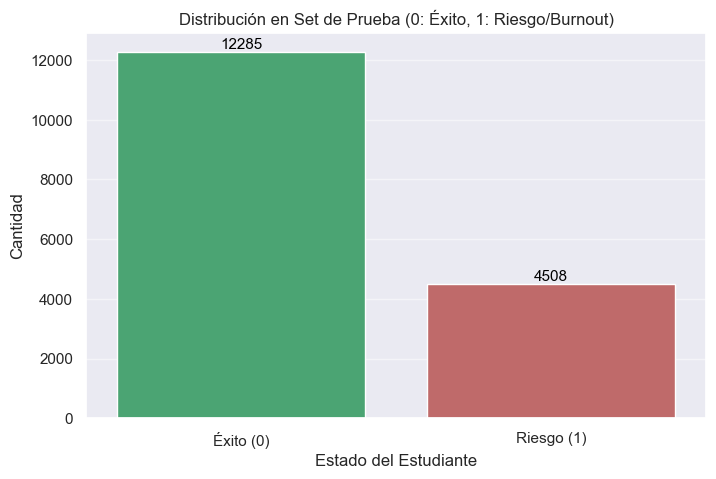

--- REPORTE DE CLASIFICACIÓN DETALLADO (LogReg) ---
              precision    recall  f1-score   support

           0       0.81      0.65      0.72     12285
           1       0.38      0.58      0.46      4508

    accuracy                           0.64     16793
   macro avg       0.60      0.62      0.59     16793
weighted avg       0.70      0.64      0.65     16793



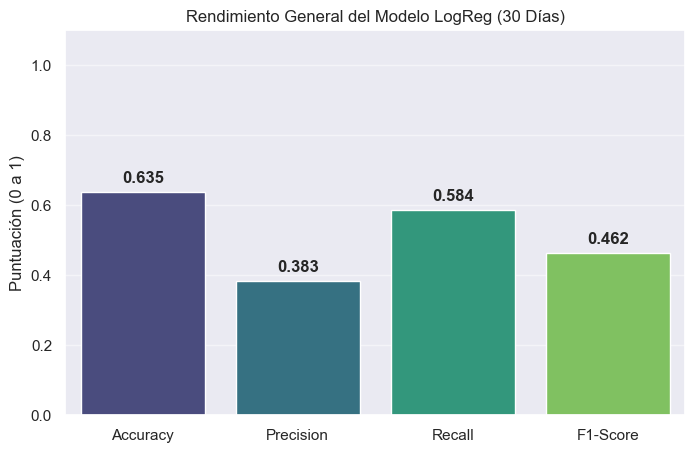

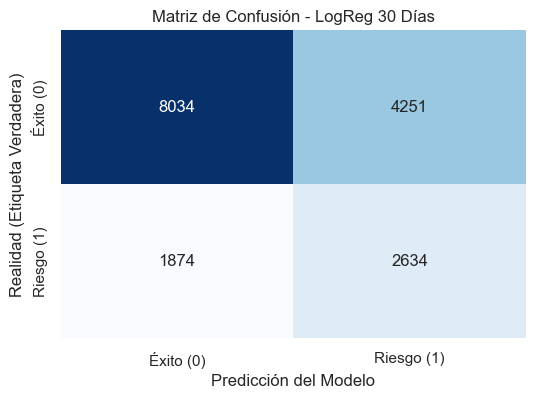

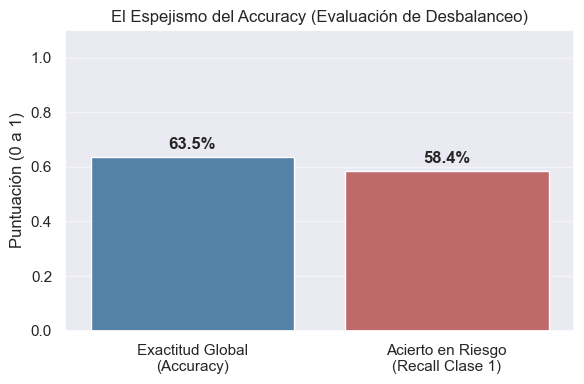

In [6]:

fig1 = plt.figure(figsize=(8, 5))

ax1 = sns.countplot(x=y_test, hue=y_test, palette=['#3CB371', '#CD5C5C'], legend=False)
plt.title('Distribución en Set de Prueba (0: Éxito, 1: Riesgo/Burnout)')
plt.xlabel('Estado del Estudiante')
plt.ylabel('Cantidad')
plt.xticks(ticks=[0, 1], labels=['Éxito (0)', 'Riesgo (1)'])

for p in ax1.patches:
    ax1.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center', fontsize=11, color='black', xytext=(0, 5), textcoords='offset points')
plt.show()


acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print("--- REPORTE DE CLASIFICACIÓN DETALLADO (LogReg) ---")
print(classification_report(y_test, y_pred, zero_division=0))


metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
metrics_values = [acc, prec, rec, f1]

fig2 = plt.figure(figsize=(8, 5))


ax2 = sns.barplot(x=metrics_names, y=metrics_values, hue=metrics_names, palette='viridis', legend=False)
plt.title('Rendimiento General del Modelo LogReg (30 Días)')
plt.ylabel('Puntuación (0 a 1)')
plt.ylim(0, 1.1)

for i, v in enumerate(metrics_values):
    ax2.text(i, v + 0.02, f"{v:.3f}", ha='center', va='bottom', fontweight='bold')
plt.show()


cm = confusion_matrix(y_test, y_pred)

fig3 = plt.figure(figsize=(6, 4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Éxito (0)', 'Riesgo (1)'],
            yticklabels=['Éxito (0)', 'Riesgo (1)'])
plt.title('Matriz de Confusión - LogReg 30 Días')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Realidad (Etiqueta Verdadera)')
plt.show()


report_dict = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
burnout_recall = report_dict['1']['recall']

fig4 = plt.figure(figsize=(6, 4))

metric_names_comp = ['Exactitud Global\n(Accuracy)', 'Acierto en Riesgo\n(Recall Clase 1)']
metric_values_comp = [acc, burnout_recall]

ax4 = sns.barplot(x=metric_names_comp, y=metric_values_comp, hue=metric_names_comp, palette=['#4682B4', '#CD5C5C'], legend=False)
plt.title('El Espejismo del Accuracy (Evaluación de Desbalanceo)')
plt.ylabel('Puntuación (0 a 1)')
plt.ylim(0, 1.1)

for i, v in enumerate(metric_values_comp):
    ax4.text(i, v + 0.02, f"{v*100:.1f}%", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()